In [ ]:
!nvidia-smi

Thu Jan  8 08:43:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

## Custom Training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt \
data=/content/drive/MyDrive/Krysztaly_plb/Data_yolo/pierwsze_dane_plb/data.yaml epochs=100 imgsz=1024 batch=8 \
patience=300 \
project=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb

/content
New https://pypi.org/project/ultralytics/8.3.213 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/drive/MyDrive/Krysztaly_plb/Data_yolo/pierwsze_dane_plb/data.yaml, epochs=100, time=None, patience=300, batch=8, imgsz=1024, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visuali

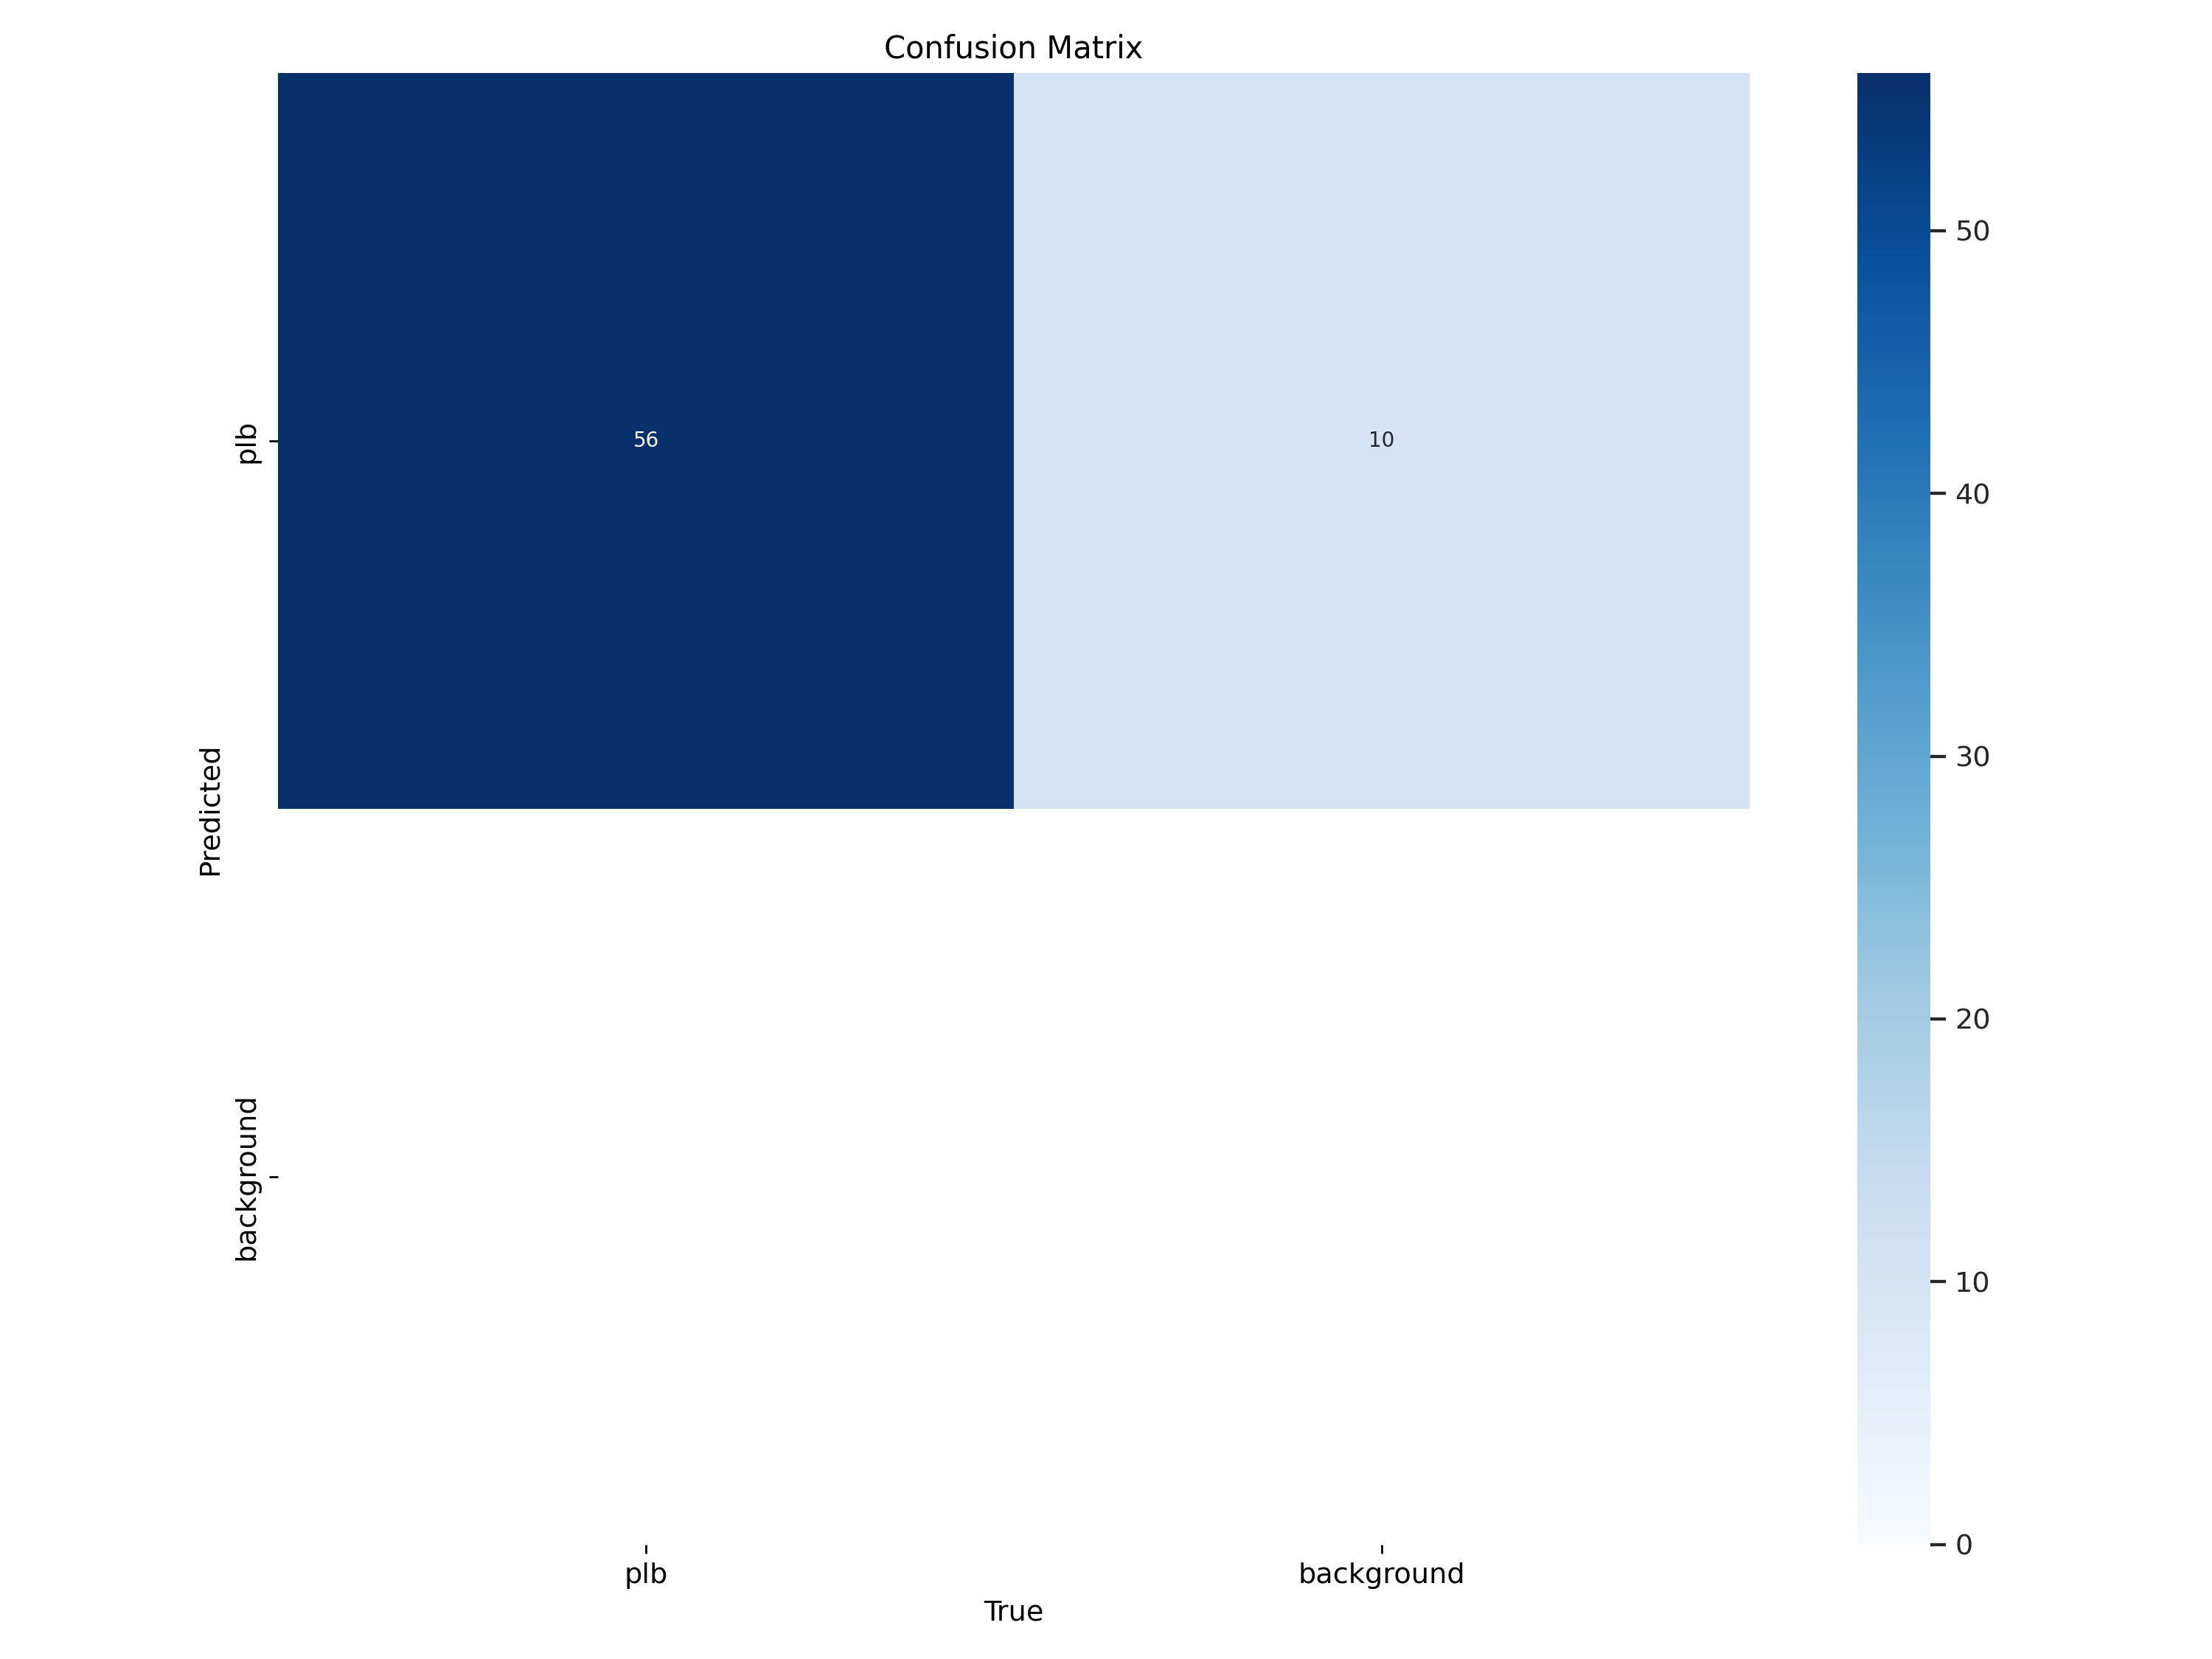

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/train/confusion_matrix.png', width=600)

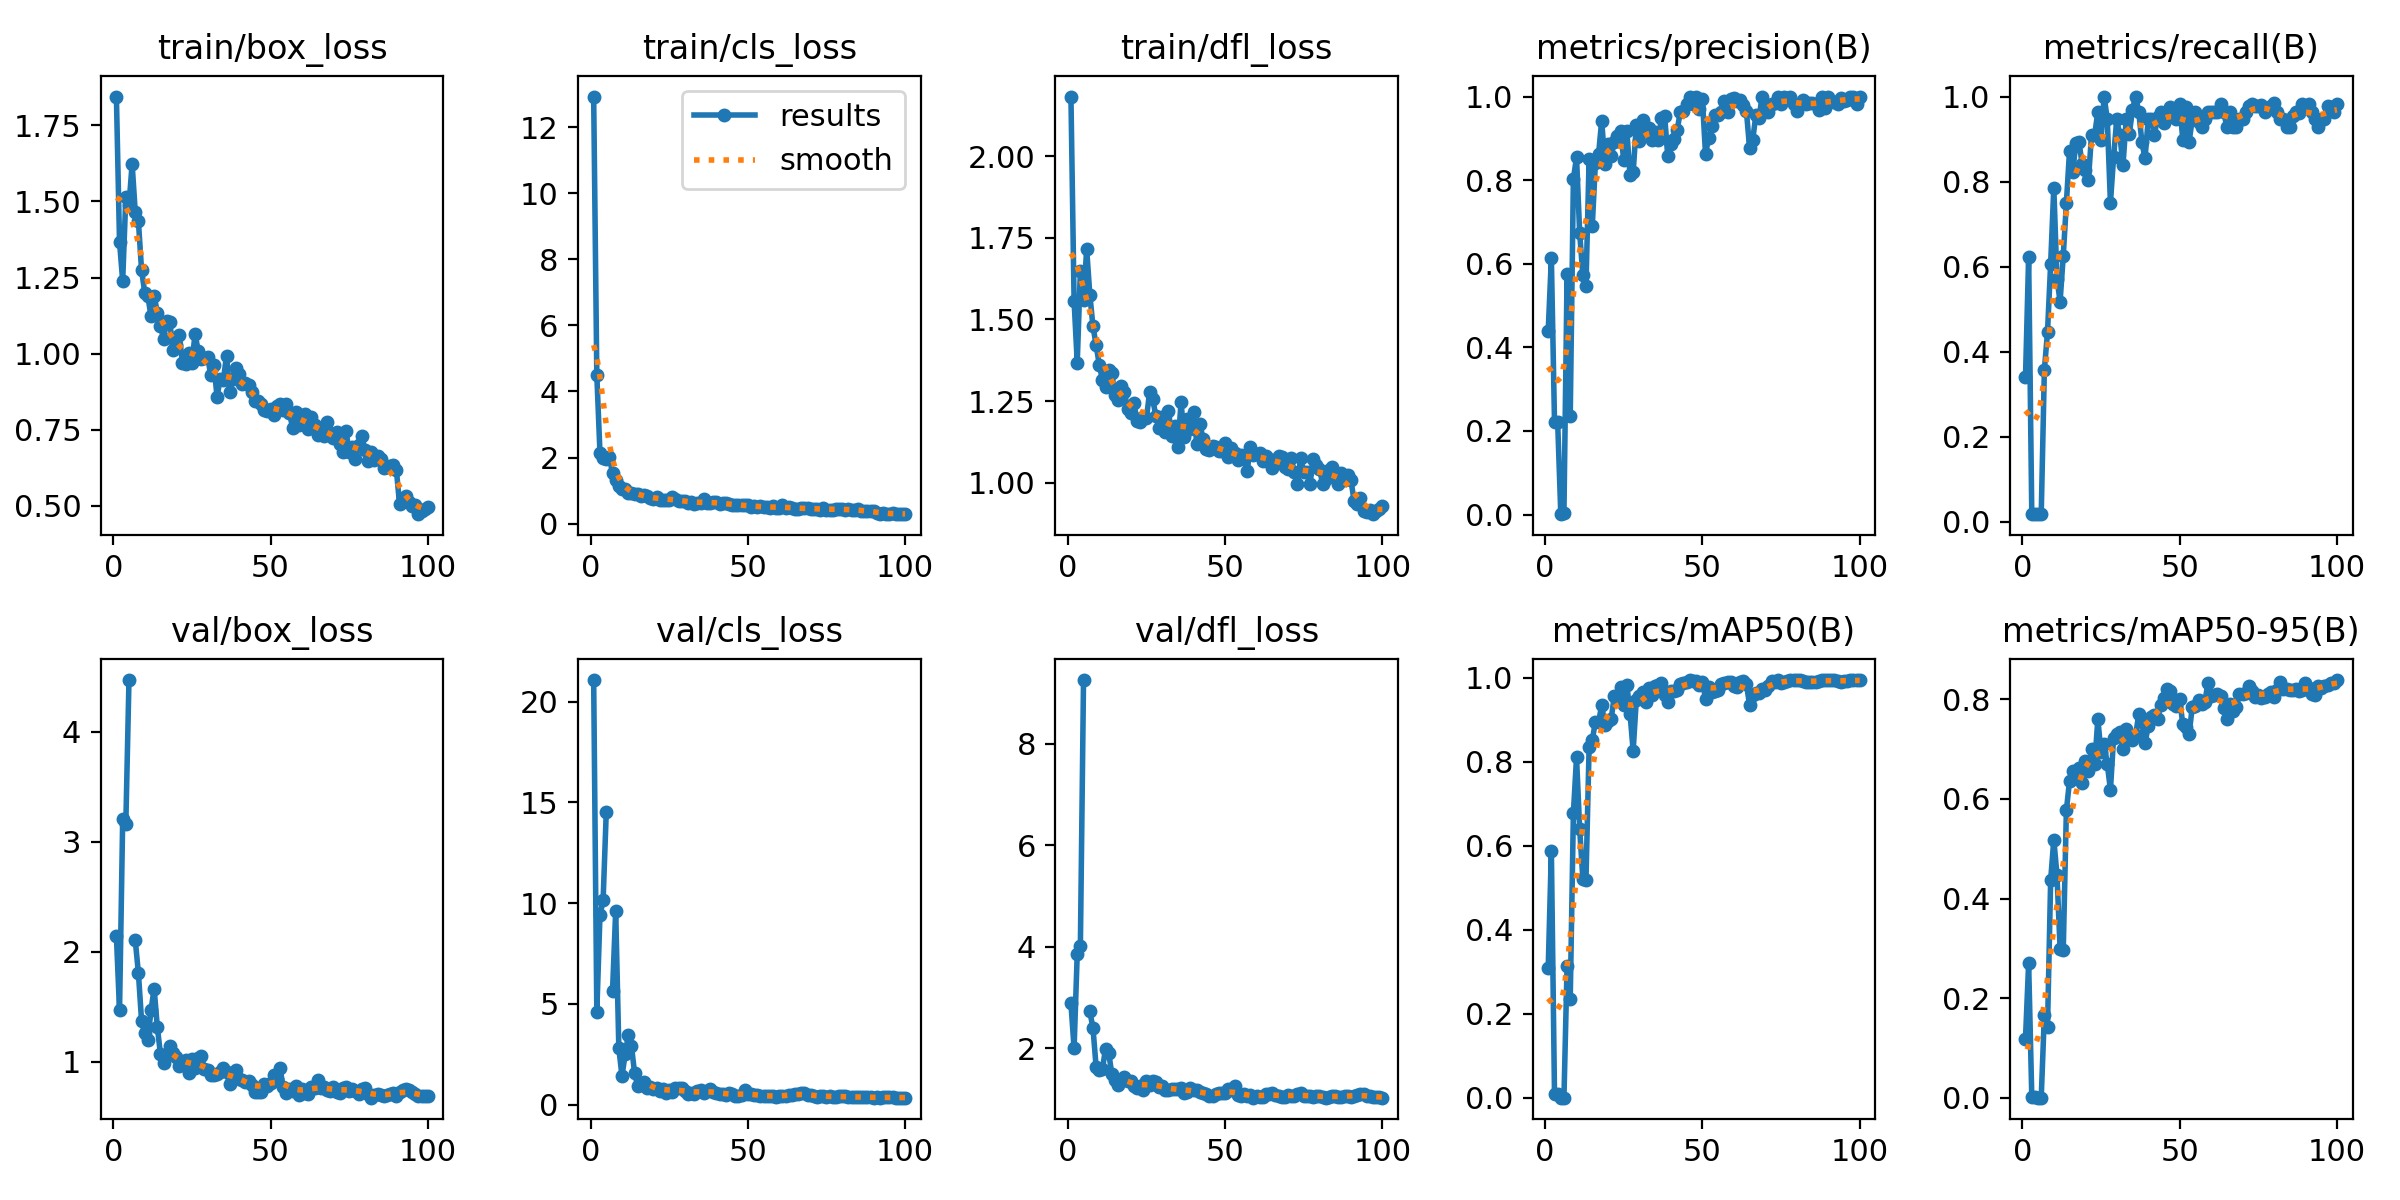

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/train/results.png', width=600)

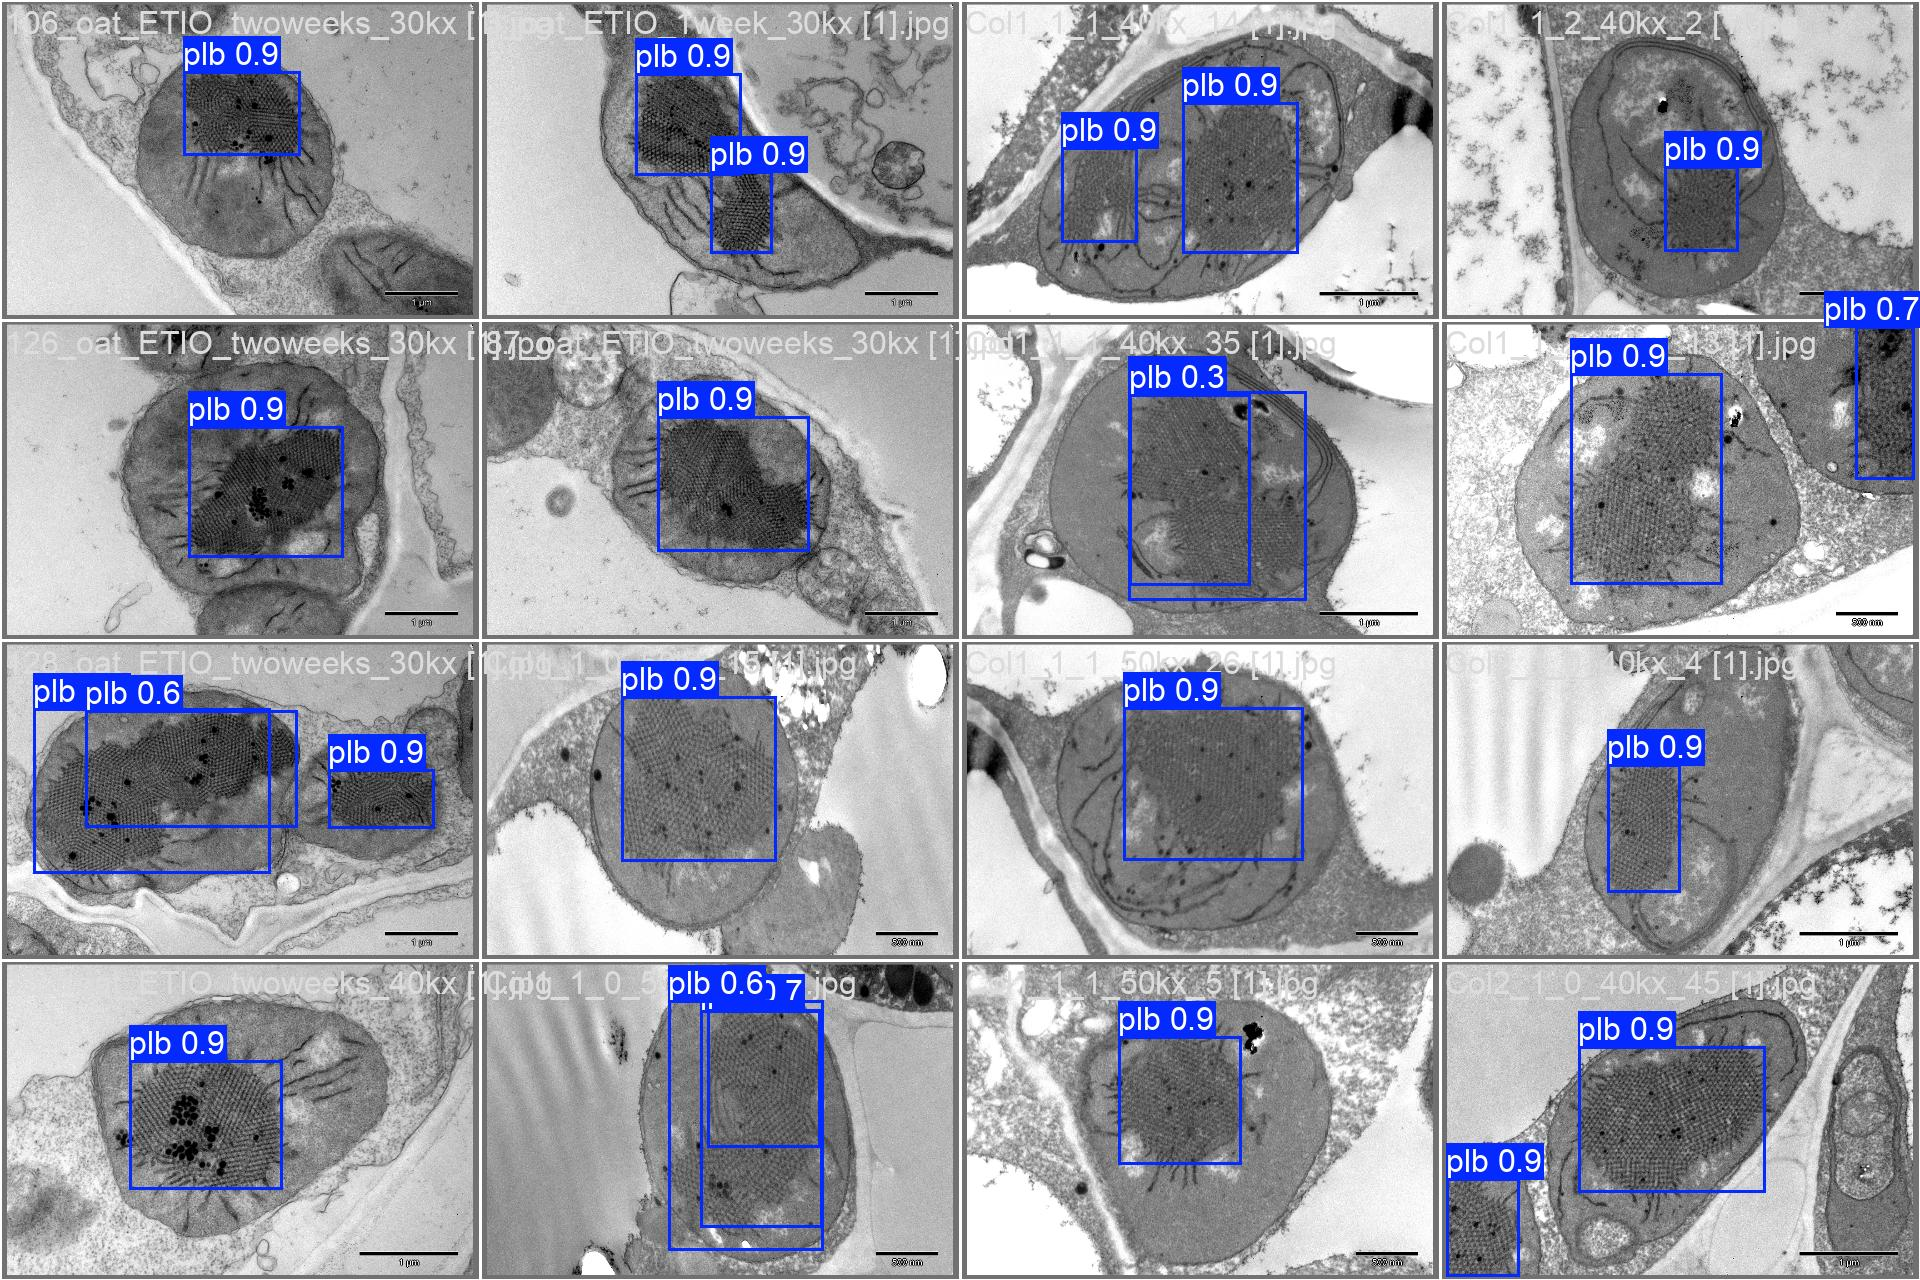

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/train/weights/best.pt \
 data=/content/drive/MyDrive/Krysztaly_plb/Data_yolo/pierwsze_dane_plb/data.yaml save_txt=True save_conf=True save=True \
 project=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/predict

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
100% 755k/755k [00:00<00:00, 25.0MB/s]
val: Scanning /content/drive/.shortcut-targets-by-id/1fyW9SoJJy4zCSbahYs28azoUqbjYf2Dy/Data_yolo/pierwsze_dane_plb/val/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% 40/40 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:42<00:00, 14.21s/it]
                   all         40         56          1      0.982      0.994      0.834
Speed: 4.0ms preprocess, 19.8ms inference, 0.0ms loss, 10.0ms postprocess per image
Results saved to /content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/predict/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference model - ALL DATASET

In [ ]:
!yolo task=detect mode=predict model=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/train/weights/best.pt \
conf=0.5 source=/content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg \
save=True save_conf=True save_txt=True \
project=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/predict

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/501 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg/00_WTara_1_0_b_40kx__(1) (1).jpg: 704x1024 2 plbs, 55.4ms
image 2/501 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg/00_WTara_1_0_b_40kx__(1).jpg: 704x1024 2 plbs, 25.2ms
image 3/501 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg/01_WTara_1_0_b_8kx__(1) (1).jpg: 704x1024 8 plbs, 25.2ms
image 4/501 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg/01_WTara_1_0_b_8kx__(1).jpg: 704x1024 8 plbs, 25.1ms
image 5/501 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg/03_WTara_1_0_b_40kx__(1) (1).jpg: 704x1024 1 plb, 25.2ms
image 6/501 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/Dataset/img_jpg/03_WTara_1_0_b_40kx__(1).jpg: 704x1024 1 plb, 25.3ms
image 7/501 /content/drive/MyDrive/Krysztaly_plb/Da

## Inference model - unique_jpgs_1601_files_907cd50

In [ ]:
!yolo task=detect mode=predict model=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/train/weights/best.pt \
conf=0.5 source=/content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50 \
save=True save_conf=True save_txt=True batch=4 \
project=/content/drive/MyDrive/Krysztaly_plb/02_training/train_1_plb/pred_unique_jpgs_1601_files_907cd50

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/1601 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50/00_WTara_1_0_b_40kx__(1).jpg: 1024x1024 2 plbs, 29.6ms
image 2/1601 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50/01.jpg: 1024x1024 2 plbs, 29.6ms
image 3/1601 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50/01_WTara_1_0_b_8kx__(1).jpg: 1024x1024 8 plbs, 29.6ms
image 4/1601 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50/02.jpg: 1024x1024 1 plb, 29.6ms
WARNING ⚠️ Image Read Error /content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50/03.jpg
image 6/1601 /content/drive/MyDrive/Krysztaly_plb/Data_yolo/unique_jpgs_1601_files_907cd50/03_WTara_1_0_b_40kx__(1).jpg: 1024x1024 1 plb, 29.5ms
image 7/1601 /content/drive/MyDrive/K